<a href="https://colab.research.google.com/github/SpringBoardMentor193s/SentinelNet/blob/khushalha/notebooks/multiclass_classn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import the Libraries

In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report
from sklearn.feature_selection import RFE
import itertools
import time
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from xgboost import XGBClassifier

2. Load Data

In [3]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train=pd.read_csv("/content/drive/MyDrive/KDDTrain+_20Percent.txt",names=col_names)
test=pd.read_csv("/content/drive/MyDrive/KDDTest-21.txt",names=col_names)
train.drop(['difficulty'], axis=1, inplace=True)
test.drop(['difficulty'], axis=1, inplace=True)


3. Shape of the Data

In [4]:
print("---Training Data---")
print(f"Shape: {train.shape}")
print("\n---Test Data---")
print(f"Shape: {test.shape}")

---Training Data---
Shape: (25192, 42)

---Test Data---
Shape: (11850, 42)


In [5]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


4. Data info

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

5. Check for missing values

In [7]:
train.isnull().sum()

,0
duration,0
protocol_type,0
service,0
flag,0
src_bytes,0
dst_bytes,0
land,0
wrong_fragment,0
urgent,0
hot,0


In [8]:
print("Total missing values:",train.isnull().sum().sum())
train=train.dropna()

Total missing values: 0


6. Statistical Information of Data

In [9]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


7. Remove Duplicates

In [10]:
print("Before removing duplicates:", train.shape)
train = train.drop_duplicates()
print("After removing duplicates:", train.shape)

Before removing duplicates: (25192, 42)
After removing duplicates: (25192, 42)


8. Top 10 types of Attacks

/tmp/ipython-input-4175320351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")


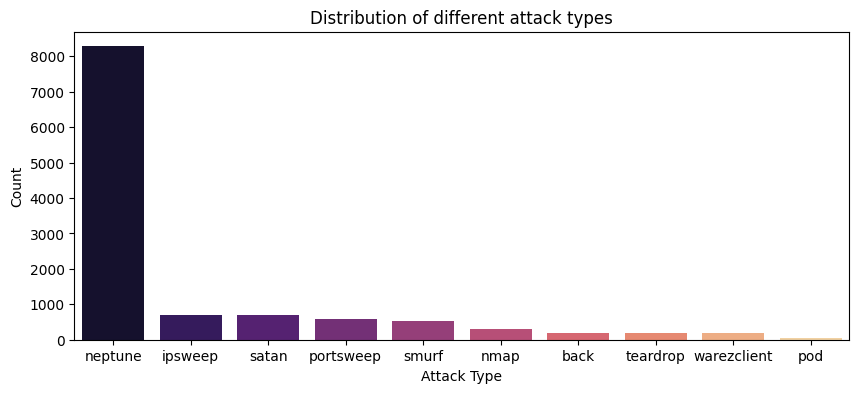

In [11]:
plt.figure(figsize=(10,4))
df_attacks=train["label"]
sns.countplot(x=df_attacks, order=df_attacks.value_counts().index[1:11], palette="magma")
plt.title("Distribution of different attack types")
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.show()

9. Label Encoding

In [12]:
def le(df):
  for col in df.columns:
    if df[col].dtype == 'object':
      label_encoder=LabelEncoder()
      df[col]=label_encoder.fit_transform(df[col])
le(train)
le(test)

In [13]:
train.drop(['num_outbound_cmds'],axis=1,inplace=True)
test.drop(['num_outbound_cmds'],axis=1,inplace=True)

In [14]:
print(f"Shape of training data after encoding: {train.shape}")
print(f"Shape of testing data after encoding: {test.shape}")

Shape of training data after encoding: (25192, 41)
Shape of testing data after encoding: (11850, 41)


In [15]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,1,19,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,11
1,0,2,41,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,11
2,0,1,46,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,9
3,0,1,22,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,11
4,0,1,22,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,11


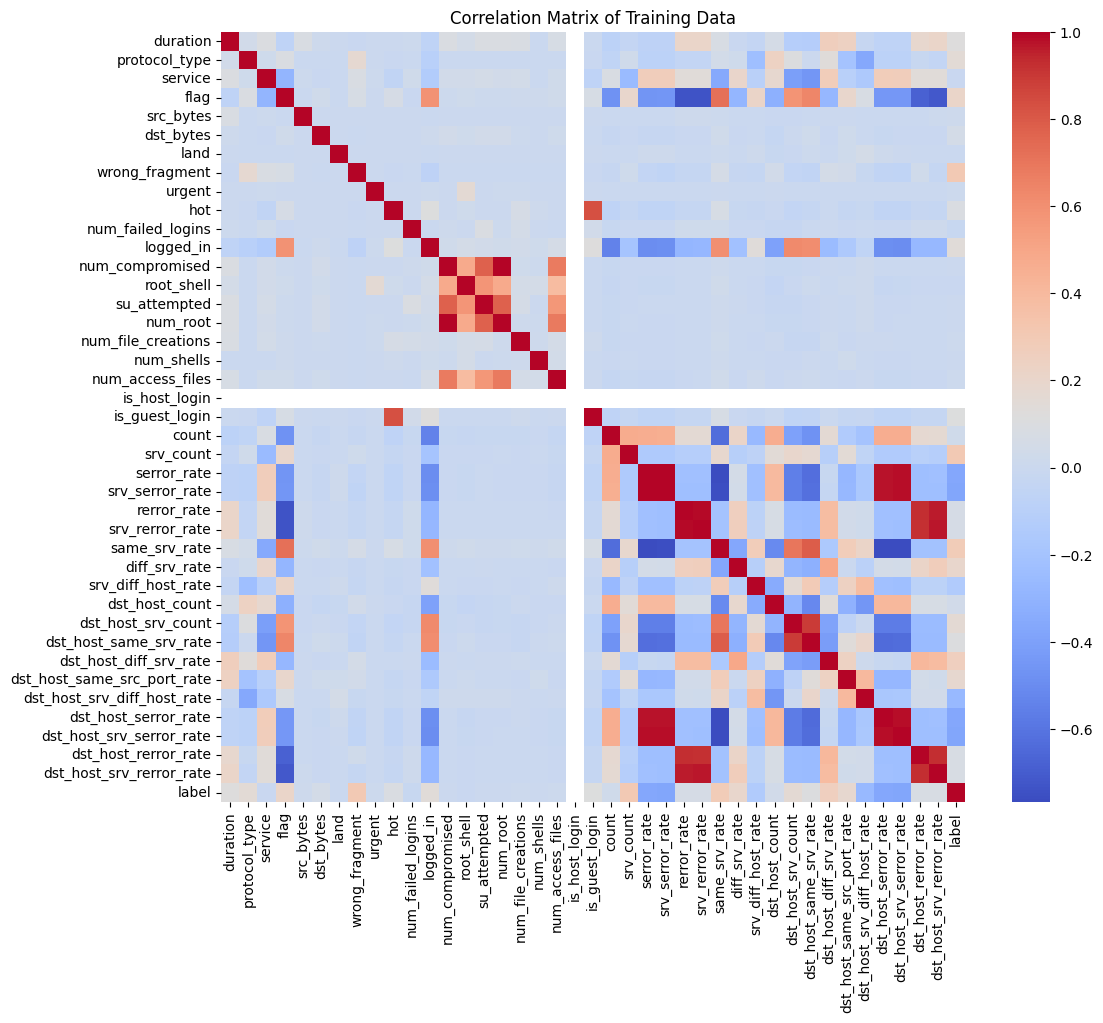

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(train.corr(), cmap='coolwarm', annot=False)
plt.title('Correlation Matrix of Training Data')
plt.show()

10. Labels

In [17]:
X = train.drop(['label'], axis=1)
Y = train['label']

In [18]:
X.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,1,19,9,491,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00
1,0,2,41,9,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
2,0,1,46,5,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
3,0,1,22,9,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
4,0,1,22,9,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [19]:
Y.head()

,label
0,11
1,11
2,9
3,11
4,11


11. Scaling

In [20]:
scale=StandardScaler()
X=scale.fit_transform(X)
# test=scale.fit_transform(test)

12. Resampling using SMOTE

Class distribution before resampling:
Counter({11: 13449, 9: 8282, 5: 710, 16: 691, 14: 587, 17: 529, 10: 301, 0: 196, 19: 188, 20: 181, 13: 38, 3: 10, 21: 7, 1: 6, 4: 5, 15: 4, 8: 2, 12: 2, 2: 1, 6: 1, 7: 1, 18: 1})
Class distribution after resampling:
Counter({11: 13449, 9: 13449, 20: 13449, 5: 13449, 14: 13449, 19: 13449, 10: 13449, 16: 13449, 17: 13449, 13: 13449, 0: 13449, 3: 13449, 8: 13449, 15: 13449, 1: 13449, 4: 13449, 21: 13449, 12: 13449, 2: 1, 6: 1, 7: 1, 18: 1})
Classes with a single sample (excluded from SMOTE): [2, 6, 7, 18]


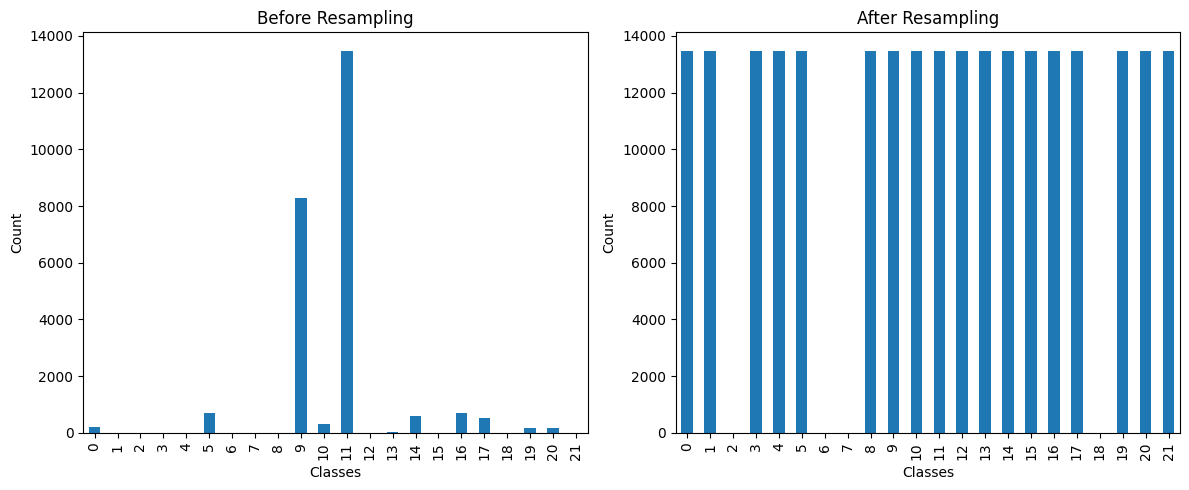

In [21]:
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
import matplotlib.pyplot as plt
import numpy as np # Import numpy for np.unique

# ----------------------------
# Assume X, y already defined
# ----------------------------

print("Class distribution before resampling:")
print(Counter(Y))

# Count the occurrences of each class in the training data
class_counts = Counter(Y)

# Identify classes with only one sample
single_sample_classes = [label for label, count in class_counts.items() if count == 1]

# Determine the target number of samples for oversampling (majority class count)
majority_class_count = max(class_counts.values())

# Define the sampling strategy: oversample all classes with more than one sample up to the majority class count
sampling_strategy = {label: majority_class_count for label, count in class_counts.items() if count > 1}


# Instantiate SMOTE with the defined sampling strategy and a smaller number of neighbors (if needed for other small classes)
# Check if there are any classes left to oversample after excluding single-sample ones
if sampling_strategy:
    # Determine a safe k_neighbors value: the minimum number of samples in the classes to be oversampled, minus 1.
    # If all remaining classes have more than 1 sample, k_neighbors=1 is safe.
    # If there are classes with 2 samples, k_neighbors must be 1.
    min_samples_in_oversampled_classes = min(sampling_strategy.values()) if sampling_strategy else 0
    # k_neighbors should be less than or equal to the number of samples in the smallest class being oversampled
    # Since we are oversampling to the majority class count, min_samples_in_oversampled_classes is the majority count.
    # We need k_neighbors to be based on the original counts of the minority classes being oversampled.
    # Let's find the minimum count among the classes included in the sampling_strategy
    min_original_minority_count = min([count for label, count in class_counts.items() if label in sampling_strategy])
    k_neighbors_value = min(5, max(1, min_original_minority_count - 1)) if min_original_minority_count > 1 else 1


    sm = SMOTE(random_state=42, sampling_strategy=sampling_strategy, k_neighbors=k_neighbors_value)

    X_resampled, y_resampled = sm.fit_resample(X, Y)

    print("Class distribution after resampling:")
    print(Counter(y_resampled))
    print(f"Classes with a single sample (excluded from SMOTE): {single_sample_classes}")

    # ----------------------------
    # Plot class distribution
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Before resampling
    pd.Series(Y).value_counts().sort_index().plot(kind='bar', ax=axes[0])
    axes[0].set_title("Before Resampling")
    axes[0].set_xlabel("Classes")
    axes[0].set_ylabel("Count")

    # After resampling
    pd.Series(y_resampled).value_counts().sort_index().plot(kind='bar', ax=axes[1])
    axes[1].set_title("After Resampling")
    axes[1].set_xlabel("Classes")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

else:
    print("No classes to oversample after excluding single-sample classes.")
    X_resampled = X
    y_resampled = Y

13. Validation Split

In [22]:
# Split the resampled data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.7, random_state=42)

In [23]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((72625, 40), (169461, 40), (72625,), (169461,))

14. Model Training & Evaluation

▶ Training Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Time: 17.70s | Testing Time: 0.07s
Train Accuracy: 0.9899 | Test Accuracy: 0.9890
▶ Training Random Forest


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Time: 24.10s | Testing Time: 4.21s
Train Accuracy: 1.0000 | Test Accuracy: 0.9997
▶ Training XGBoost


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:06:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being s

Training Time: 19.58s | Testing Time: 2.38s
Train Accuracy: 0.9999 | Test Accuracy: 0.9995

Summary of Model Performance

--- Logistic Regression ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9523
           1       0.97      1.00      0.99      9410
           3       1.00      1.00      1.00      9419
           4       1.00      1.00      1.00      9458
           5       0.98      0.99      0.98      9334
           7       0.00      0.00      0.00         1
           8       1.00      1.00      1.00      9413
           9       1.00      1.00      1.00      9331
          10       0.95      0.98      0.96      9396
          11       0.98      0.91      0.94      9336
          12       1.00      1.00      1.00      9379
          13       1.00      1.00      1.00      9377
          14       0.99      1.00      0.99      9366
          15       0.99      1.00      1.00      9580
   

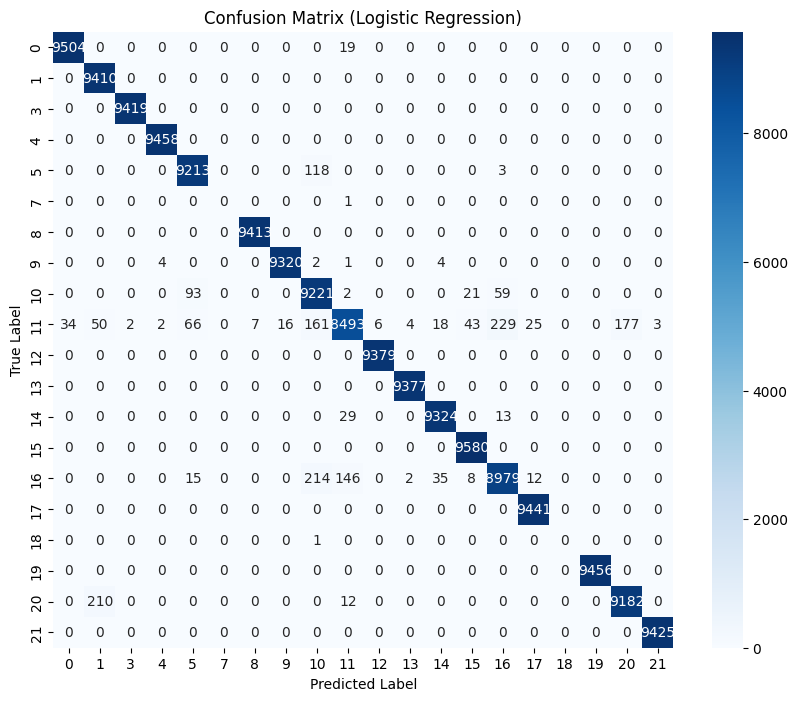


--- Random Forest ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9523
           1       1.00      1.00      1.00      9410
           3       1.00      1.00      1.00      9419
           4       1.00      1.00      1.00      9458
           5       1.00      1.00      1.00      9334
           7       0.00      0.00      0.00         1
           8       1.00      1.00      1.00      9413
           9       1.00      1.00      1.00      9331
          10       1.00      1.00      1.00      9396
          11       1.00      1.00      1.00      9336
          12       1.00      1.00      1.00      9379
          13       1.00      1.00      1.00      9377
          14       1.00      1.00      1.00      9366
          15       1.00      1.00      1.00      9580
          16       1.00      1.00      1.00      9411
          17       1.00      1.00      1.00      9441
          18       0.0

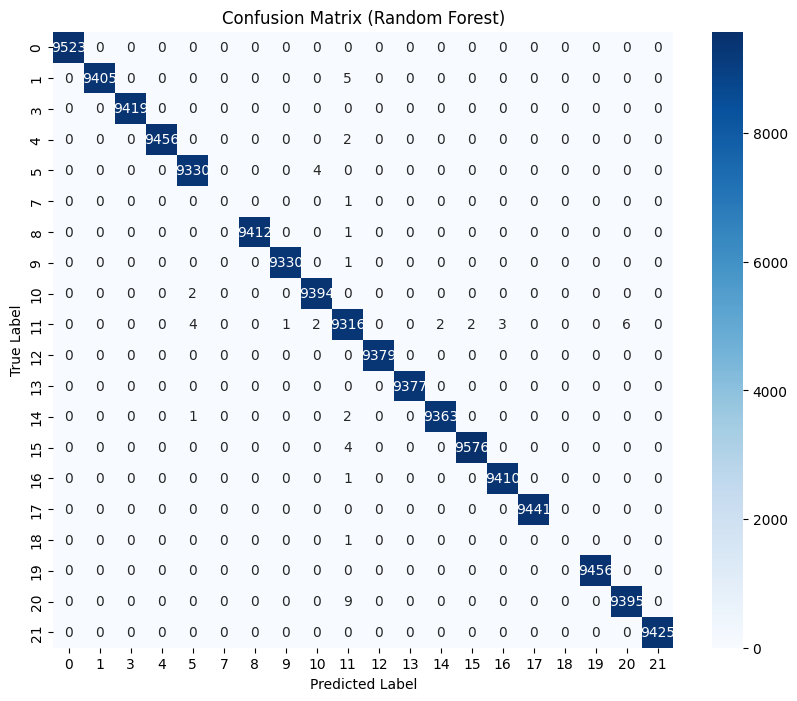


--- XGBoost ---

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9523
           1       1.00      1.00      1.00      9410
           3       1.00      1.00      1.00      9419
           4       1.00      1.00      1.00      9458
           5       1.00      1.00      1.00      9334
           7       0.00      0.00      0.00         1
           8       1.00      1.00      1.00      9413
           9       1.00      1.00      1.00      9331
          10       1.00      1.00      1.00      9396
          11       1.00      1.00      1.00      9336
          12       1.00      1.00      1.00      9379
          13       1.00      1.00      1.00      9377
          14       1.00      1.00      1.00      9366
          15       1.00      1.00      1.00      9580
          16       1.00      1.00      1.00      9411
          17       1.00      1.00      1.00      9441
          18       0.00     

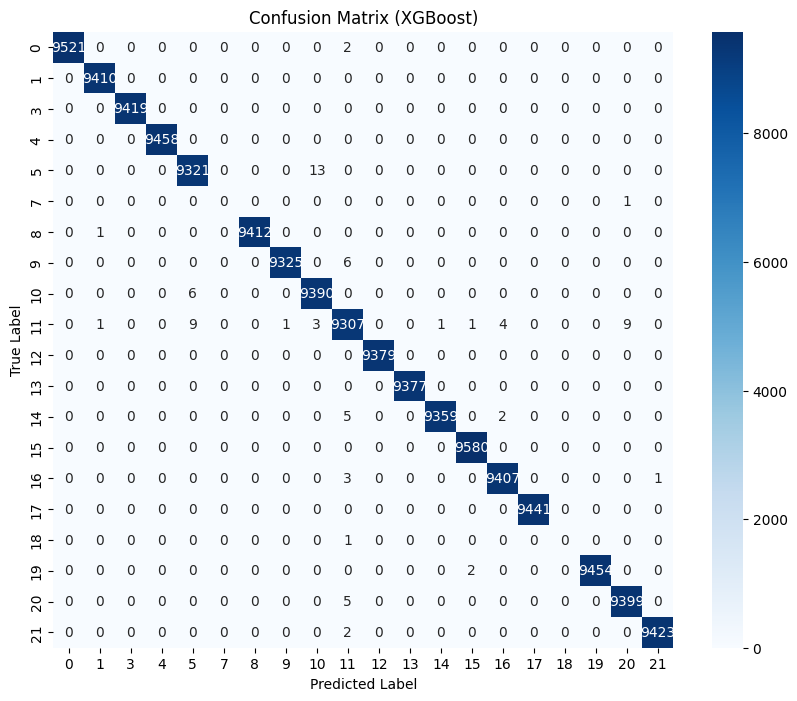

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
}

results = {}

# Train all models
# Use the resampled data for training
# Use the resampled test data for evaluation as well
x_train_used = x_train
y_train_used = y_train
x_test_used = x_test
y_test_used = y_test


for name, model in models.items():
    print("="*60)
    print(f"▶ Training {name}")

    # Training time
    start = time.time()

    # Map the labels to a contiguous range for XGBoost if needed
    if name == "XGBoost":
        unique_labels = sorted(y_train_used.unique()) # Get unique labels and sort them
        label_map = {label: i for i, label in enumerate(unique_labels)}
        y_train_mapped = y_train_used.map(label_map)
        model.fit(x_train_used, y_train_mapped)
    else:
        model.fit(x_train_used, y_train_used)

    train_time = time.time() - start

    # Training performance
    if name == "XGBoost":
        y_train_pred_mapped = model.predict(x_train_used)
        # Convert predictions back to original labels for evaluation
        reverse_label_map = {i: label for label, i in label_map.items()}
        y_train_pred = np.array([reverse_label_map[pred] for pred in y_train_pred_mapped])
    else:
        y_train_pred = model.predict(x_train_used)


    train_acc = accuracy_score(y_train_used, y_train_pred)

    # Testing time
    start = time.time()
    if name == "XGBoost":
        y_test_pred_mapped = model.predict(x_test_used)
        # Convert predictions back to original labels for evaluation
        reverse_label_map = {i: label for label, i in label_map.items()}
        y_test_pred = np.array([reverse_label_map[pred] for pred in y_test_pred_mapped])
    else:
        y_test_pred = model.predict(x_test_used)

    test_time = time.time() - start
    test_acc = accuracy_score(y_test_used, y_test_pred)

    # Store results
    results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Training Time": train_time,
        "Testing Time": test_time,
        "Confusion Matrix": confusion_matrix(y_test_used, y_test_pred),
        "Classification Report": classification_report(y_test_used, y_test_pred)
    }

    # Print results
    print(f"Training Time: {train_time:.2f}s | Testing Time: {test_time:.2f}s")
    print(f"Train Accuracy: {train_acc:.4f} | Test Accuracy: {test_acc:.4f}")

# After training, print classification reports and plot confusion matrices
print("\n" + "="*60)
print("Summary of Model Performance")
print("="*60)

for name, result in results.items():
    print(f"\n--- {name} ---")
    print("\nClassification Report (Test Data):")
    print(result["Classification Report"])

    # Confusion Matrix
    cm = result["Confusion Matrix"]
    plt.figure(figsize=(10, 8)) # Increased figure size for better readability
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=sorted(np.unique(y_test_used)),
                yticklabels=sorted(np.unique(y_test_used)))
    plt.title(f"Confusion Matrix ({name})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

15. Comparing the Models

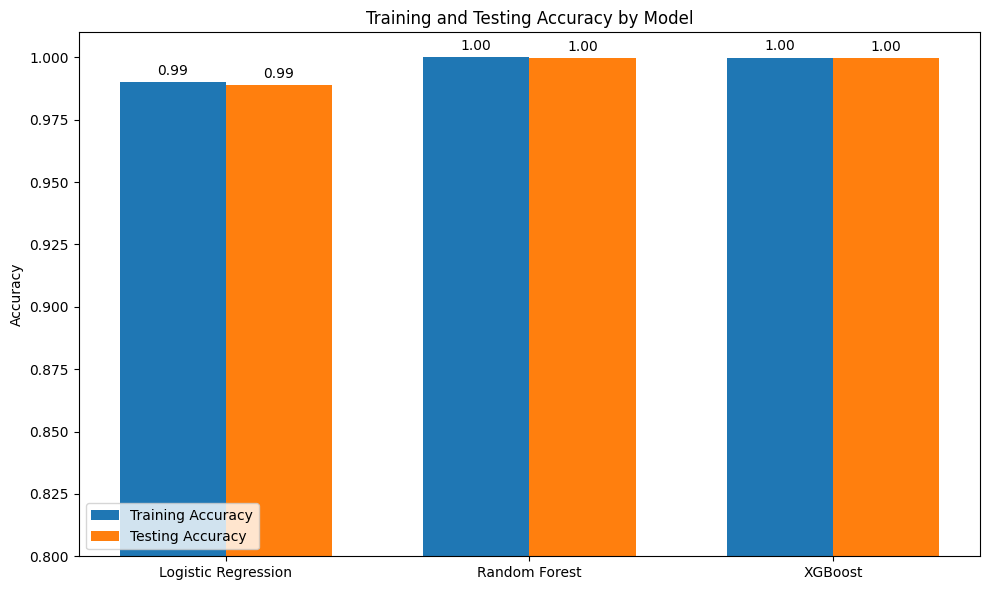

In [25]:
model_names = list(results.keys())
train_accuracy = [metrics['Train Accuracy'] for metrics in results.values()]
test_accuracy = [metrics['Test Accuracy'] for metrics in results.values()]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_accuracy, width, label='Training Accuracy')
rects2 = ax.bar(x + width/2, test_accuracy, width, label='Testing Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Training and Testing Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('%.2f' % height,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.ylim(0.8, 1.01) # Adjust y-axis limits for better visualization
plt.tight_layout()
plt.show()

16. Testing

In [36]:
# The true labels are numerical (0-21), printing 'Attack'/'Normal' is misleading
# and likely relies on an unstated mapping (e.g., 0=normal, non-0=attack).
# We will use a more reliable index and print the actual numerical labels.

example_index = 150000 # A random index likely to be one of the SMOTE-generated samples
example_data = x_test[example_index].reshape(1, -1)
true_label = y_test.iloc[example_index]

print(f"Example index: {example_index}")
print(f"True numerical label: {true_label}")
print("-" * 30)

# Make predictions with each model
for name, model in models.items():
    prediction = model.predict(example_data)[0]

    # Handle XGBoost's mapped prediction
    if name == "XGBoost":
        # y_test_used was not mapped, so we need to map the prediction back
        reverse_label_map = {i: label for label, i in label_map.items()}
        prediction = reverse_label_map.get(prediction, prediction) # Get original label or keep if not found

    print(f"{name} Prediction: {prediction}")

Example index: 150000
True numerical label: 9
------------------------------
Logistic Regression Prediction: 9
Random Forest Prediction: 9
XGBoost Prediction: 9
